<a href="https://colab.research.google.com/github/Nivetha-B93/Data-Cleaning-Pipeline-for-SaaS-Dataset/blob/main/Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 4-Data Visualization**

1) Loading the Taxis Dataset

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# Load the 'taxis' dataset
df = sns.load_dataset("taxis")
df

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


In [7]:
df.dtypes

,0
pickup,datetime64[ns]
dropoff,datetime64[ns]
passengers,int64
distance,float64
fare,float64
tip,float64
tolls,float64
total,float64
color,object
payment,object


## **Handling Missing Values**
2)Check for missing values in the dataset and identify columns with missing data.

In [4]:
# Set aesthetic style for all plots
sns.set_theme(style="whitegrid")

In [5]:
# Check for missing values in the dataset
print("Missing values per column:\n")
print(df.isnull().sum())

print("\nPercentage of missing values per column:\n")
print((df.isnull().sum() / len(df) * 100).round(2))

# Identify columns that actually have missing data
cols_with_missing = df.columns[df.isnull().any()].tolist()
print("\nColumns with missing data:", cols_with_missing)

Missing values per column:

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

Percentage of missing values per column:

pickup             0.00
dropoff            0.00
passengers         0.00
distance           0.00
fare               0.00
tip                0.00
tolls              0.00
total              0.00
color              0.00
payment            0.68
pickup_zone        0.40
dropoff_zone       0.70
pickup_borough     0.40
dropoff_borough    0.70
dtype: float64

Columns with missing data: ['payment', 'pickup_zone', 'dropoff_zone', 'pickup_borough', 'dropoff_borough']


## **● Impute missing values using appropriate strategies based on the column type**

In [6]:
# Impute missing values in categorical columns using mode

categorical_cols = ['payment', 'pickup_zone', 'dropoff_zone', 'pickup_borough', 'dropoff_borough']

for col in categorical_cols:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f"Filled '{col}' with mode: {mode_val}")

# Verify no missing values remain in these columns
print("\nMissing values after imputation:\n")
print(df[categorical_cols].isnull().sum())

Filled 'payment' with mode: credit card
Filled 'pickup_zone' with mode: Midtown Center
Filled 'dropoff_zone' with mode: Upper East Side North
Filled 'pickup_borough' with mode: Manhattan
Filled 'dropoff_borough' with mode: Manhattan

Missing values after imputation:

payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


## **3) Visualizations using Matplotlib/Pandas Plot:**

★ Line Chart
Plot a line chart to visualize the fare over time, using the pickup timestamp as the x-axis and
fare as the y-axis. Ensure the pickup column is converted to a datetime format before plotting.

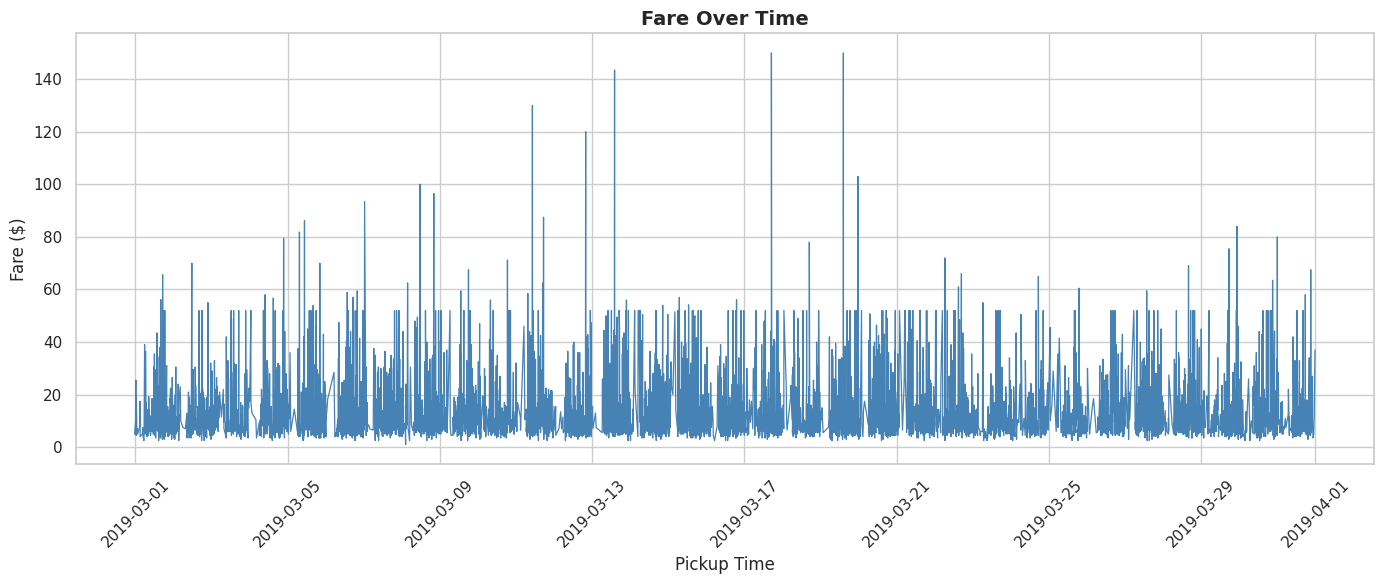

In [9]:
# Ensure pickup column is in datetime format
df['pickup'] = pd.to_datetime(df['pickup'])

# Sort by pickup time for a clean line chart
df_sorted = df.sort_values('pickup')

# Plot fare over time
plt.figure(figsize=(14, 6))
plt.plot(df_sorted['pickup'], df_sorted['fare'], linewidth=0.9, color='steelblue')
plt.title('Fare Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Pickup Time')
plt.ylabel('Fare ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

line chart tells us fares are highly variable per trip with occasional spikes, but it doesn't reveal a clean trend — for that, the daily-averaged version will help us draw conclusion.(e.g., whether average fares increased/decreased over the data collection period, or stayed roughly stable)

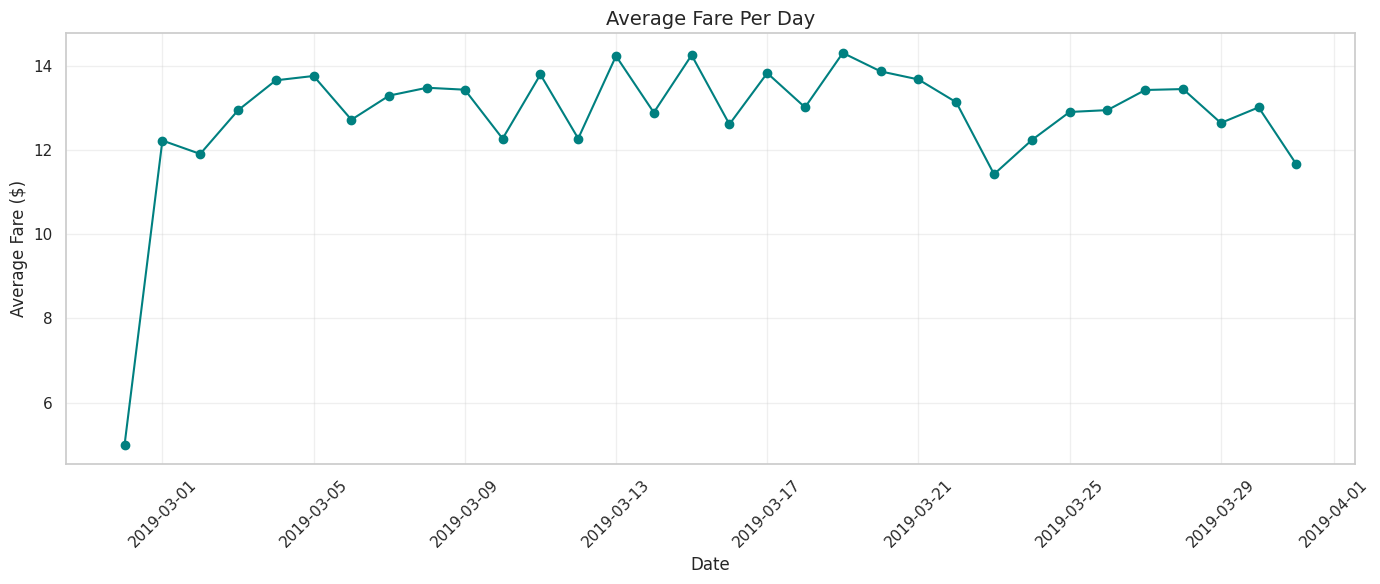

In [11]:
# Ensure pickup column is in datetime format
df['pickup'] = pd.to_datetime(df['pickup'])

# Set pickup as index temporarily for resampling
df_time = df.set_index('pickup').sort_index()

# Resample: average fare per day
daily_fare = df_time['fare'].resample('D').mean()

# Plot the aggregated trend
plt.figure(figsize=(14, 6))
plt.plot(daily_fare.index, daily_fare.values, marker='o', linewidth=1.5, color='teal')
plt.title('Average Fare Per Day', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Average Fare ($)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## **Inference:**
No long-term trend — fares neither rose nor fell systematically over the period.
Fluctuation is normal day-to-day variation, not a pattern.Taxi fares were stable on average across the dataset's time span

## **★ Bar Chart**
Create a bar chart to show the total fare for each pickup_borough. Group the data by
pickup_borough and sum the fare for each group.

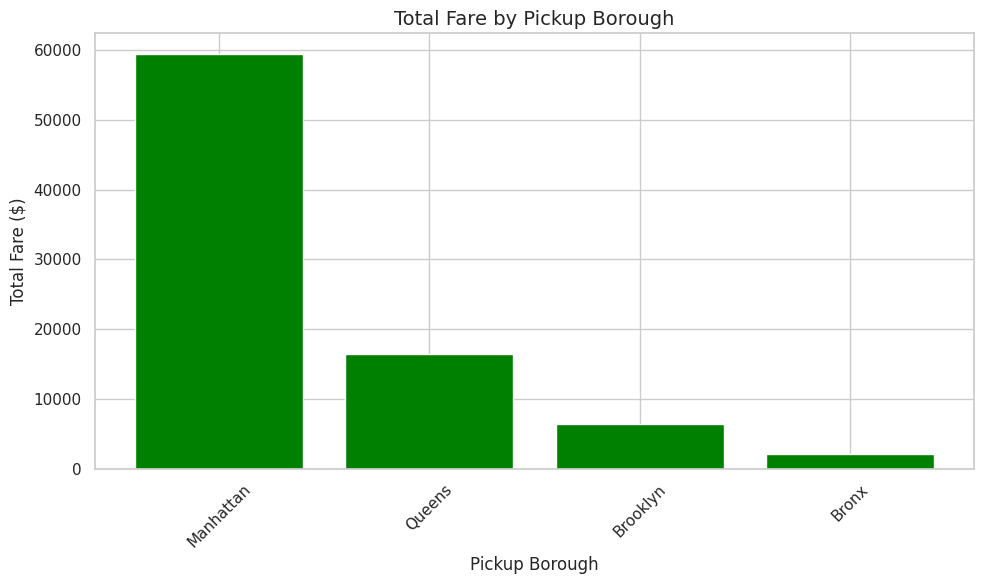

pickup_borough
Manhattan    59426.42
Queens       16382.06
Brooklyn      6327.48
Bronx         2078.91
Name: fare, dtype: float64


In [14]:
# Group by pickup_borough and sum the fare
borough_fare = df.groupby('pickup_borough')['fare'].sum().sort_values(ascending=False)

# Plot bar chart
plt.figure(figsize=(10, 6))
plt.bar(borough_fare.index, borough_fare.values, color='green')
plt.title('Total Fare by Pickup Borough', fontsize=14)
plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(borough_fare)

# Inference:
Manhattan accounts for the overwhelming majority of total taxi fare revenue by pickup borough, indicating pickup activity (and thus revenue) is heavily concentrated there.

## **Pie Chart**
Plot a pie chart showing the distribution of trips based on the payment method (credit card,
cash, etc.). Each slice should represent the count of trips for a specific payment method.

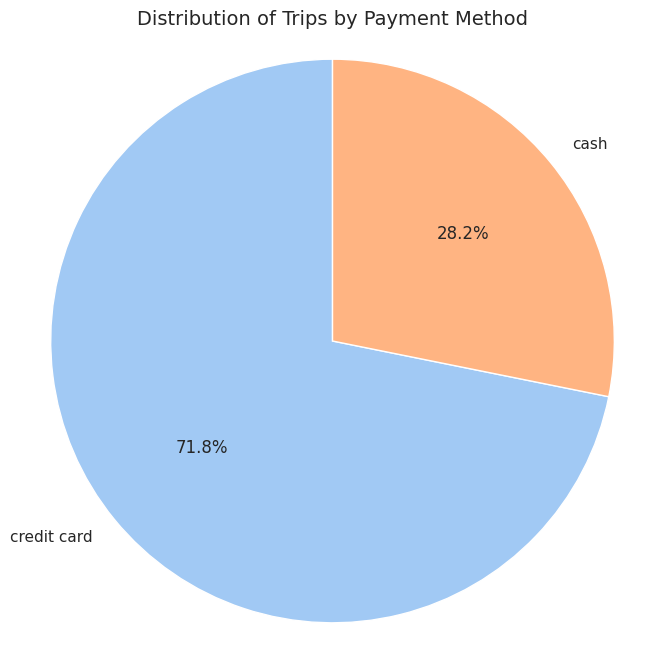

payment
credit card    4621
cash           1812
Name: count, dtype: int64


In [15]:
# Count trips by payment method
payment_counts = df['payment'].value_counts()

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%',
        startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribution of Trips by Payment Method', fontsize=14)
plt.axis('equal')
plt.show()

print(payment_counts)

## **Inference:**
The majority of taxi trips are paid via credit card, indicating a strong customer preference for cashless payment over cash

# **★ Histogram**
Create a histogram to visualize the distribution of distance. Customize the number of bins for
better granularity and ensure the plot is easy to interpret.

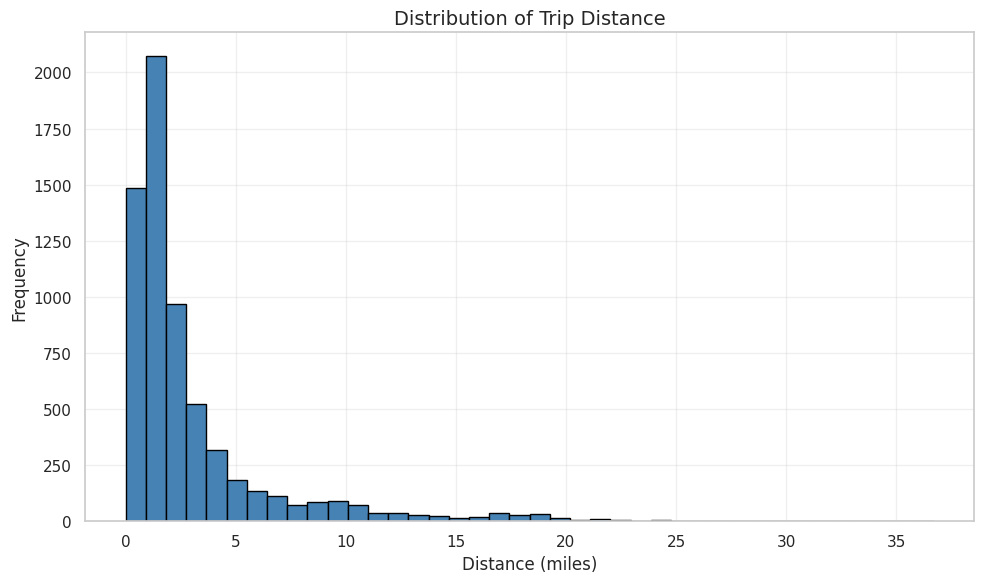

count    6433.000000
mean        3.024617
std         3.827867
min         0.000000
25%         0.980000
50%         1.640000
75%         3.210000
max        36.700000
Name: distance, dtype: float64


In [19]:
# Histogram of trip distance
plt.figure(figsize=(10, 6))
plt.hist(df['distance'], bins=40, color='steelblue', edgecolor='black')
plt.title('Distribution of Trip Distance', fontsize=14)
plt.xlabel('Distance (miles)')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(df['distance'].describe())

## **Inference:**
The majority of taxi trips are short-distance (mostly under 3 miles), with a long right tail of infrequent longer trips — reflecting typical urban, point-to-point taxi usage rather than long-haul travel

## **★ Box Plot**
Plot a box plot to visualize the distribution of tip amounts for each pickup_borough. Use
pickup_borough as the categorical axis and tip as the numeric axis.

<Figure size 1000x600 with 0 Axes>

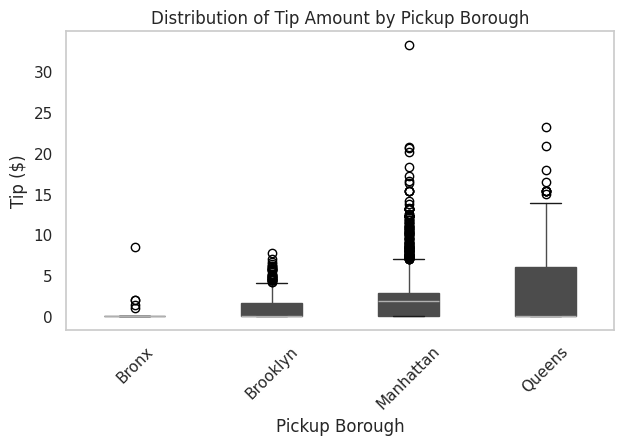

In [21]:

plt.figure(figsize=(10, 6))
df.boxplot(column='tip', by='pickup_borough', grid=False, patch_artist=True)
plt.title('Distribution of Tip Amount by Pickup Borough')
plt.suptitle('')  # removes the default pandas subtitle
plt.xlabel('Pickup Borough')
plt.ylabel('Tip ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **Inference:**
Tip amounts vary more in boroughs with higher trip volume and longer-distance rides (like Manhattan and Queens), while boroughs with fewer trips show tighter, less variable tip distributions — and most tips cluster at the lower end with a handful of high-tip outliers pulling the spread upward.

## Visualizations using Seaborn:

/tmp/ipykernel_521/1782608478.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='pickup_borough', data=df, palette='pastel', order=df['pickup_borough'].value_counts().index)


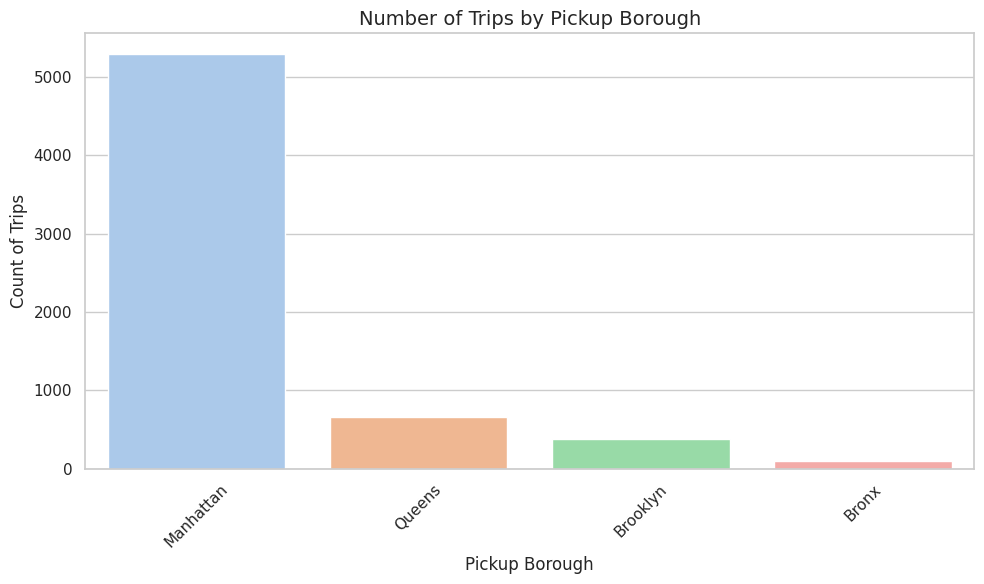

In [22]:
# Count plot: number of trips per pickup_borough
plt.figure(figsize=(10, 6))
sns.countplot(x='pickup_borough', data=df, palette='pastel', order=df['pickup_borough'].value_counts().index)
plt.title('Number of Trips by Pickup Borough', fontsize=14)
plt.xlabel('Pickup Borough')
plt.ylabel('Count of Trips')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Inference:
Taxi trip pickups are heavily concentrated in Manhattan, with all other boroughs (especially Brooklyn, Bronx, and Staten Island) accounting for only a small fraction of total trips

# **★ Scatter Plot**
Plot a scatterplot to show the relationship between distance and fare. Use distance on the
x-axis and fare on the y-axis to visualize any correlation. Color the points based on the
pickup_borough to differentiate the trips by their respective boroughs.

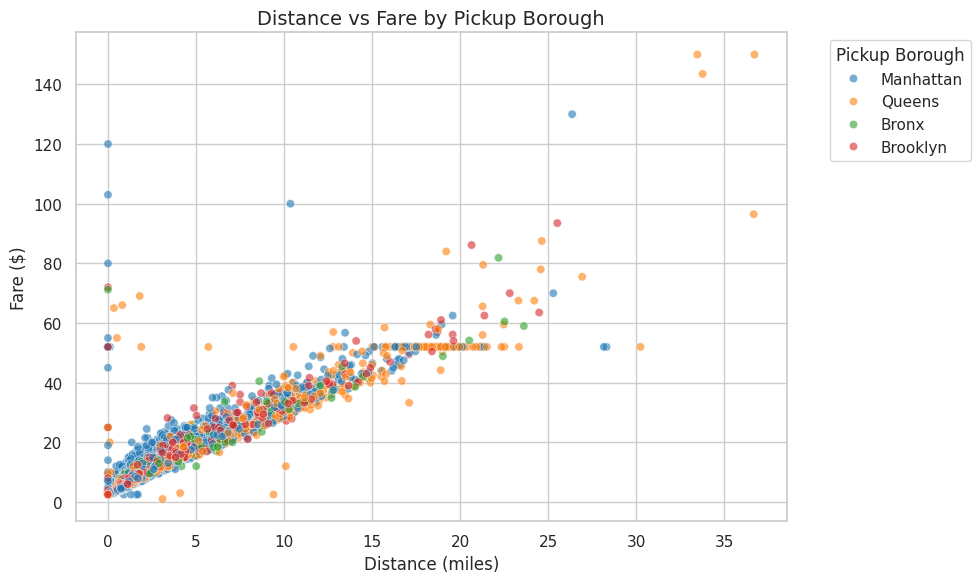

In [23]:
# Scatter plot: distance vs fare, colored by pickup_borough
plt.figure(figsize=(10, 6))
sns.scatterplot(x='distance', y='fare', hue='pickup_borough', data=df, palette='tab10', alpha=0.6)
plt.title('Distance vs Fare by Pickup Borough', fontsize=14)
plt.xlabel('Distance (miles)')
plt.ylabel('Fare ($)')
plt.legend(title='Pickup Borough', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# **Inference:**
Fare increases proportionally with distance (a clear positive linear relationship), and Manhattan trips cluster at the short-distance/low-fare end while boroughs like Queens show longer, higher-fare trips — likely reflecting airport travel

## **★ Heatmap**
Plot a heatmap to visualize the correlation between numerical variables such as distance, fare,
tip, tolls, and total. Use a correlation matrix to highlight the relationships.

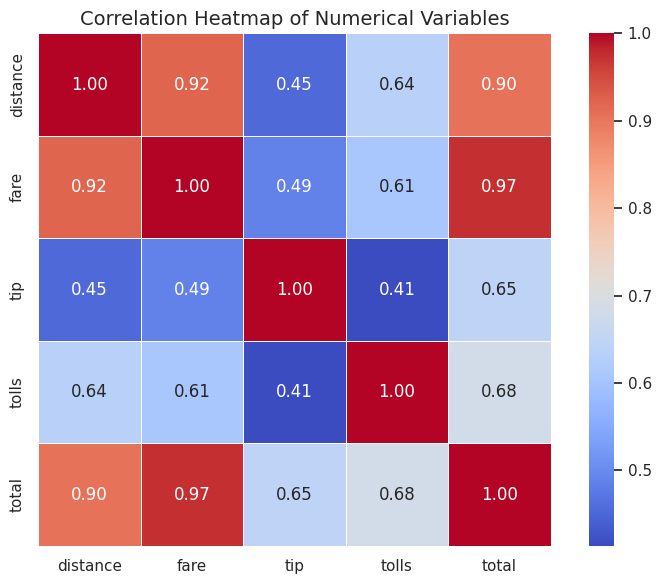

          distance      fare       tip     tolls     total
distance  1.000000  0.920108  0.452589  0.635267  0.904676
fare      0.920108  1.000000  0.488612  0.609307  0.974358
tip       0.452589  0.488612  1.000000  0.413619  0.646186
tolls     0.635267  0.609307  0.413619  1.000000  0.683142
total     0.904676  0.974358  0.646186  0.683142  1.000000


In [24]:
# Correlation heatmap for numerical variables
numeric_cols = ['distance', 'fare', 'tip', 'tolls', 'total']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Heatmap of Numerical Variables', fontsize=14)
plt.tight_layout()
plt.show()

print(corr_matrix)

## **Inference:**
Fare, distance, and total are strongly interrelated (as expected, since fare is largely distance-based and total is built from fare), tip shows a moderate positive relationship with trip cost, while tolls are largely independent — only affecting a subset of trips on specific routes.

# **★ Pair Plot**
Create a pair plot to visualize the pairwise relationships between distance, fare, tip, and total.
Color the data points according to the pickup_zone column. to compare how different zones
affect these variables.

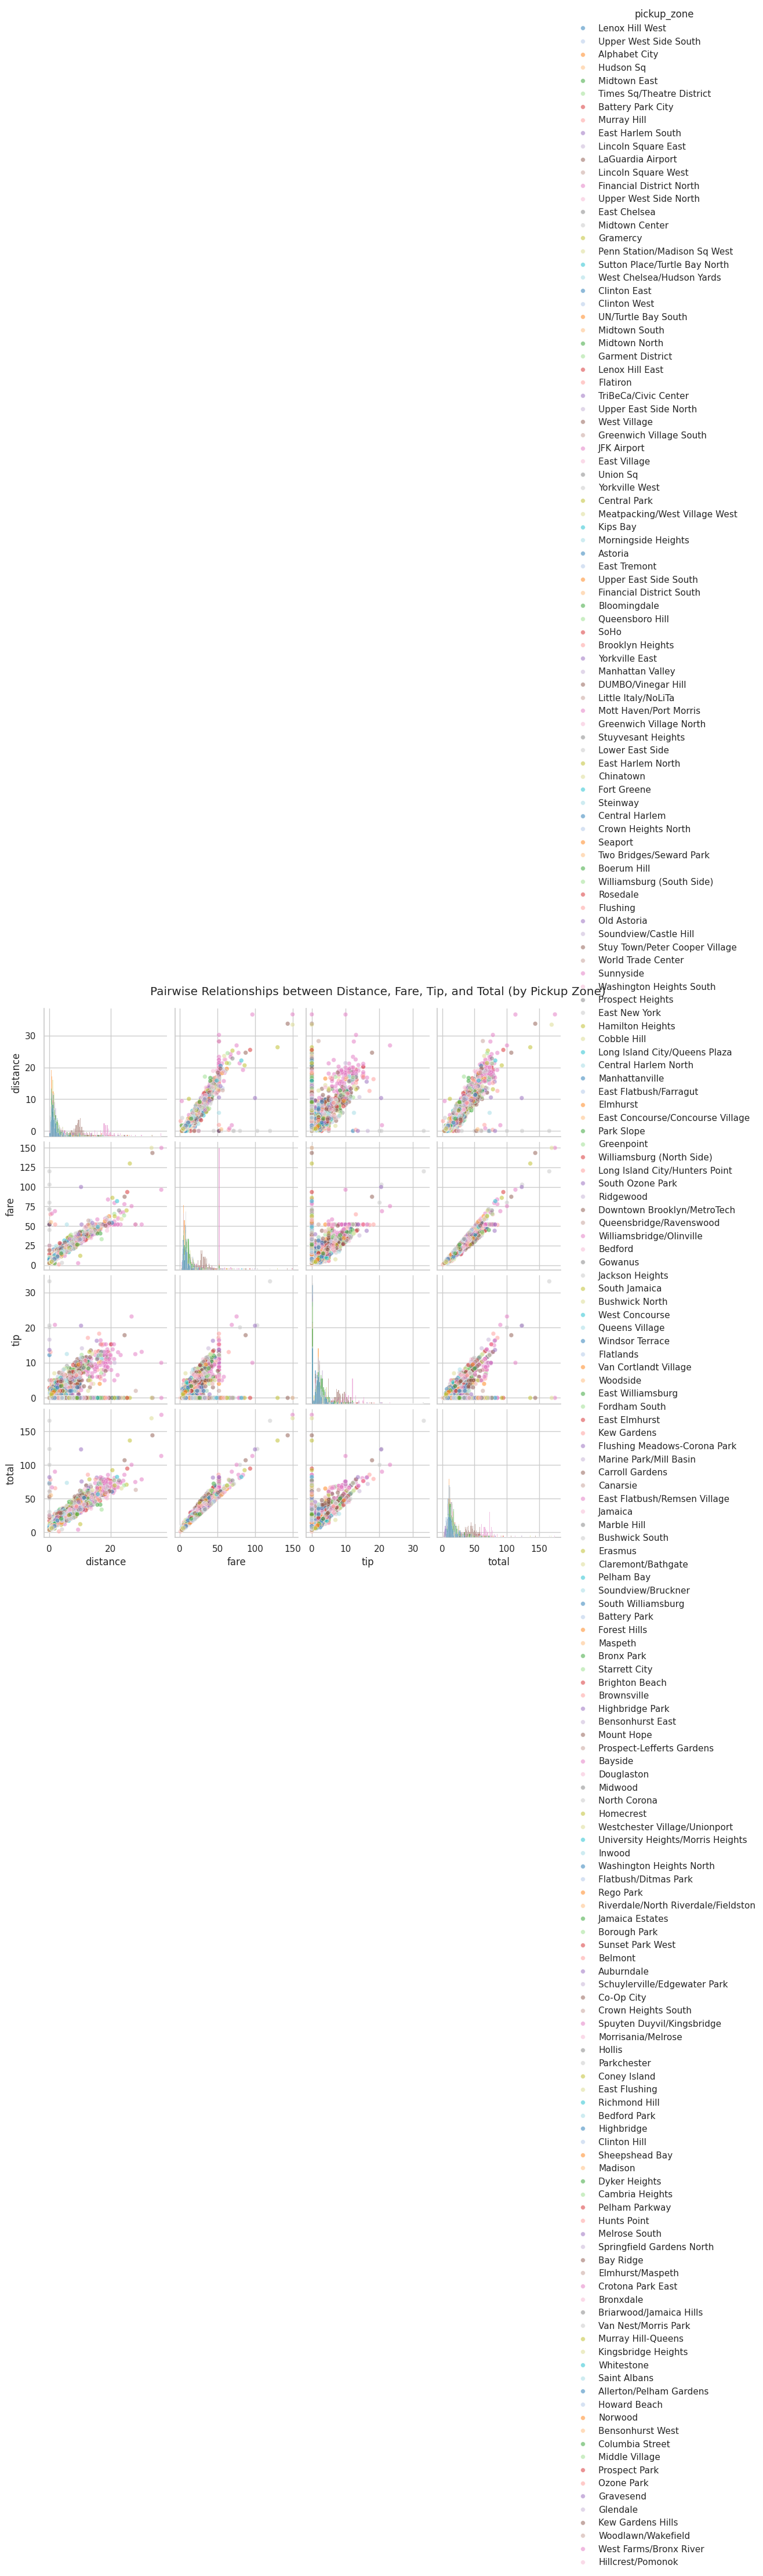

In [25]:
# Pair plot: pairwise relationships between distance, fare, tip, and total, colored by pickup_zone
sns.pairplot(df, vars=['distance', 'fare', 'tip', 'total'], hue='pickup_zone', palette='tab20',
             plot_kws={'alpha': 0.5, 's': 30}, diag_kind='hist')
plt.suptitle('Pairwise Relationships between Distance, Fare, Tip, and Total (by Pickup Zone)', y=1.02)
plt.show()

Inference:
Distance, fare, and total are strongly and linearly related, tip is more loosely correlated due to inconsistent tipping behavior, and while the plot was colored by pickup_zone

## **★ Violin Plot**
Plot a violin plot to show the distribution of fare for each payment method. Use the payment
method as the categorical axis and fare as the numeric axis to visualize its distribution.

/tmp/ipykernel_521/1969119352.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='payment', y='fare', data=df, palette='pastel')


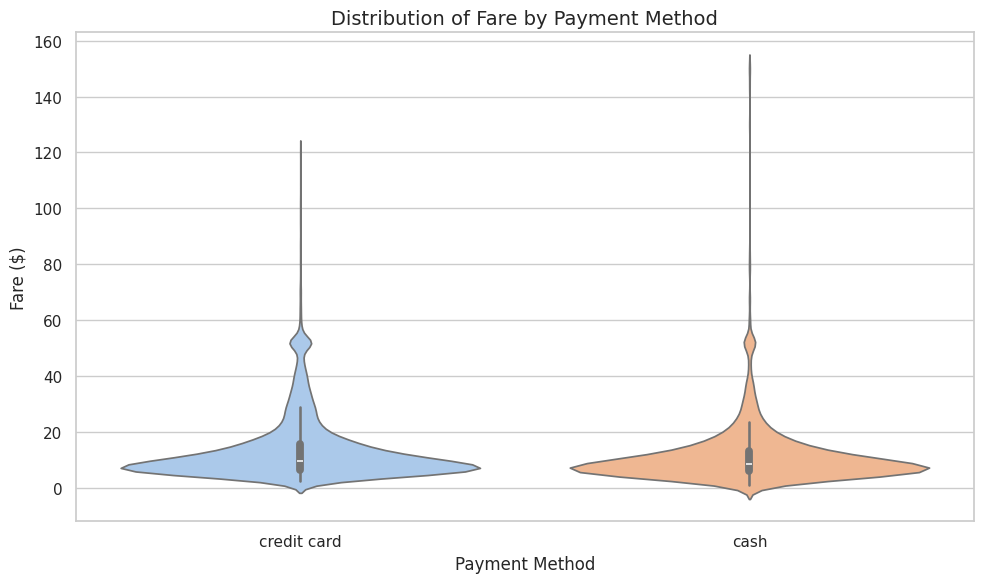

In [26]:
# Violin plot: fare distribution by payment method
plt.figure(figsize=(10, 6))
sns.violinplot(x='payment', y='fare', data=df, palette='pastel')
plt.title('Distribution of Fare by Payment Method', fontsize=14)
plt.xlabel('Payment Method')
plt.ylabel('Fare ($)')
plt.tight_layout()
plt.show()

Inference:
Fare distributions are similar in shape (right-skewed) for both payment methods, with credit card trips showing a slightly wider range extending to higher fares — suggesting payment method has a modest link to fare amount, likely driven by trip type rather than payment preference itself